<a href="https://colab.research.google.com/github/rashmib21/Data-Analysis-of-Stock-Market-from-2016-to-2026/blob/main/volume.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pmdarima odfpy pandas openpyxl

In [ ]:
import pandas as pd
import numpy as np
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from math import sqrt

# Load the data
try:
    df = pd.read_excel('/content/Hindustan_copper.ods', engine='odf')
except FileNotFoundError:
    print("Error: 'Hindustan_copper.ods' not found. Please ensure the file is in the correct path.")
    raise

display(df.head())

,symbol,datetime,open,high,low,close,volume
0,HINDALCO,2016-01-04 00:00:00+05:30,84.20,85.90,80.4,80.75,8706224
1,HINDALCO,2016-01-05 00:00:00+05:30,82.00,83.95,80.6,82.60,9819068
2,HINDALCO,2016-01-06 00:00:00+05:30,82.40,82.85,79.7,80.55,6494446
3,HINDALCO,2016-01-07 00:00:00+05:30,79.00,79.40,76.1,76.65,8098318
4,HINDALCO,2016-01-08 00:00:00+05:30,77.45,78.15,75.2,76.90,6800939


### Data Preparation

- Convert the datetime column to datetime objects.
- Set the datetime column as the index and sort it.
- Assign business day frequency and forward-fill missing values.
- Extract the 'Volume' column as the target series.

In [ ]:
# The original dataframe has a 'Date' column with non-date strings (e.g., 'HINDALCO')
# and a 'datetime' column with actual datetime information.
# The user's request implies the 'datetime' column should be used as the primary date index.

# Convert the 'datetime' column to datetime objects
df['datetime'] = pd.to_datetime(df['datetime'])

# Set 'datetime' column as index and rename it to 'Date'
df.set_index('datetime', inplace=True)
df.index.name = 'Date'

# Sort the index
df.sort_index(inplace=True)

# Rename the 'volume' column to 'Volume'
df.rename(columns={'volume': 'Volume'}, inplace=True)

# Keep only the 'Volume' column as the dataframe for time series analysis
df = df[['Volume']]

# Assign business day frequency and forward-fill missing values
df = df.asfreq('B', method='ffill')

# Extract the volume column as the target series
series = df['Volume']

print("Prepared series info:")
series.info()
display(series.head())

Prepared series info:
<class 'pandas.core.series.Series'>
DatetimeIndex: 2671 entries, 2016-01-04 00:00:00+05:30 to 2026-03-30 00:00:00+05:30
Freq: B
Series name: Volume
Non-Null Count  Dtype
--------------  -----
2671 non-null   int64
dtypes: int64(1)
memory usage: 41.7 KB


,Volume
Date,
2016-01-04 00:00:00+05:30,8706224
2016-01-05 00:00:00+05:30,9819068
2016-01-06 00:00:00+05:30,6494446
2016-01-07 00:00:00+05:30,8098318
2016-01-08 00:00:00+05:30,6800939


### Data Splitting

Split the data into 80% for training and 20% for testing, maintaining time order.

In [ ]:
train_size = int(len(series) * 0.8)
train, test = series[0:train_size], series[train_size:len(series)]

print(f"Train set size: {len(train)}")
print(f"Test set size: {len(test)}")

display(train.head())
display(test.head())

Train set size: 2136
Test set size: 535


,Volume
Date,
2016-01-04 00:00:00+05:30,8706224
2016-01-05 00:00:00+05:30,9819068
2016-01-06 00:00:00+05:30,6494446
2016-01-07 00:00:00+05:30,8098318
2016-01-08 00:00:00+05:30,6800939


,Volume
Date,
2024-03-12 00:00:00+05:30,3703670
2024-03-13 00:00:00+05:30,5712435
2024-03-14 00:00:00+05:30,10349338
2024-03-15 00:00:00+05:30,8467660
2024-03-18 00:00:00+05:30,4282437


### ARIMA Model Selection

Use `auto_arima` to find the best (p,d,q) order for the non-seasonal ARIMA model on the training data. Given the spiky nature of volume data, `max_p` and `max_q` are set to 5.

In [ ]:
model_arima = auto_arima(train,
                         seasonal=False,
                         stepwise=True,
                         suppress_warnings=True,
                         error_action='ignore',
                         max_p=5, max_q=5)

print("Best ARIMA order (p,d,q):", model_arima.order)
print(model_arima.summary())

Best ARIMA order (p,d,q): (1, 1, 3)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2136
Model:               SARIMAX(1, 1, 3)   Log Likelihood              -36080.645
Date:                Thu, 23 Apr 2026   AIC                          72171.290
Time:                        17:18:59   BIC                          72199.621
Sample:                    01-04-2016   HQIC                         72181.658
                         - 03-11-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8150      0.048     17.114      0.000       0.722       0.908
ma.L1         -1.4867      0.051    -29.130      0.000      -1.587      -1.387
ma.L2          0

### Walk-Forward Validation and Prediction

Perform walk-forward validation: for each point in the test set, retrain ARIMA on all data up to that point and predict only 1 step ahead, appending the actual value to history each time.

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

# Use the order already found by auto_arima BEFORE the loop
best_order = model_arima.order  # already determined earlier
print(f"Using ARIMA order: {best_order}")

history = list(train)
predictions = list()

for t in range(len(test)):
    # Only fit ARIMA with fixed order — NO auto_arima inside loop
    model = ARIMA(history, order=best_order)
    model_fit = model.fit()
    yhat = model_fit.forecast()[0]
    predictions.append(yhat)
    obs = test.iloc[t]
    history.append(obs)

    # Progress indicator every 50 steps
    if t % 50 == 0:
        print(f'Step {t}/{len(test)} — predicted={yhat:.3f}, expected={obs:.3f}')

# Convert to pandas Series
predictions_series = pd.Series(predictions, index=test.index)
print(f"\nDone! Total predictions: {len(predictions_series)}")

Using ARIMA order: (1, 1, 3)
Step 0/535 — predicted=6862128.013, expected=3703670.000
Step 50/535 — predicted=5225878.461, expected=15976672.000
Step 100/535 — predicted=6384780.490, expected=6714850.000
Step 150/535 — predicted=6286555.727, expected=5418558.000
Step 200/535 — predicted=4446074.414, expected=4800541.000
Step 250/535 — predicted=5919398.504, expected=10249548.000
Step 300/535 — predicted=4759356.584, expected=2778131.000
Step 350/535 — predicted=4700801.068, expected=4815703.000
Step 400/535 — predicted=3825002.945, expected=3783529.000
Step 450/535 — predicted=4127627.731, expected=4237151.000
Step 500/535 — predicted=5923134.080, expected=4101779.000

Done! Total predictions: 535


### Evaluation and Results

Calculate the Root Mean Squared Error (RMSE) and display a DataFrame comparing the actual and predicted values for the test set.

In [ ]:
# Ensure that the 'test' and 'predictions_series' variables are defined by running the preceding cells.
from math import sqrt
from sklearn.metrics import mean_squared_error

rmse = sqrt(mean_squared_error(test, predictions_series))
print(f'Test RMSE: {rmse:.3f}')

# Create a DataFrame for actual vs. predicted values
comparison_df = pd.DataFrame({'Actual_Volume': test, 'Predicted_Volume': predictions_series})
display(comparison_df.head())

Test RMSE: 3295917.378


,Actual_Volume,Predicted_Volume
Date,,
2024-03-12 00:00:00+05:30,3703670,6.862128e+06
2024-03-13 00:00:00+05:30,5712435,6.115487e+06
2024-03-14 00:00:00+05:30,10349338,6.475958e+06
2024-03-15 00:00:00+05:30,8467660,7.934604e+06
2024-03-18 00:00:00+05:30,4282437,7.695023e+06


### Visualization

Visualize the train, test, and predicted 'Volume' data. This includes a full view and a zoomed-in view of the test set.

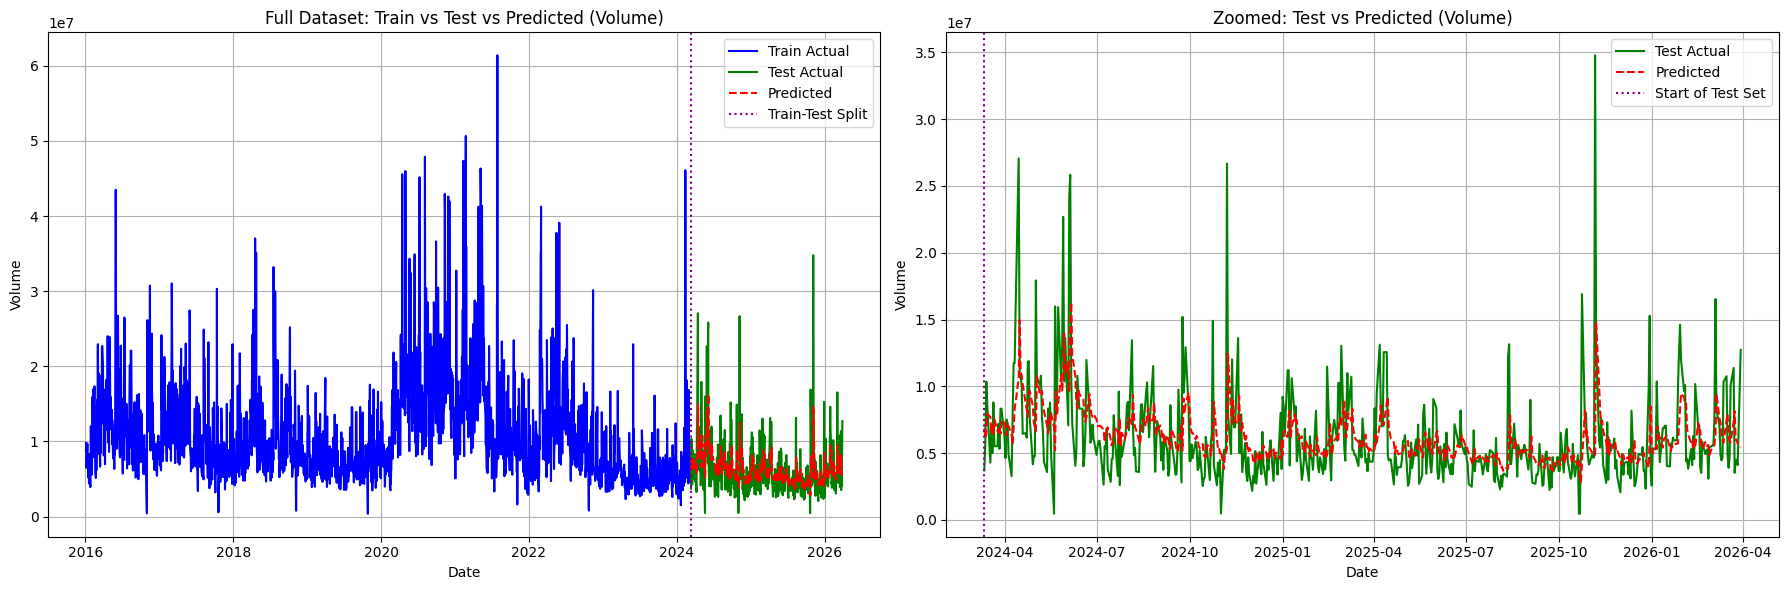

In [ ]:
plt.figure(figsize=(18, 6))

# Subplot 1: Full Dataset View
plt.subplot(1, 2, 1)
plt.plot(train.index, train, color='blue', label='Train Actual')
plt.plot(test.index, test, color='green', label='Test Actual')
plt.plot(predictions_series.index, predictions_series, color='red', linestyle='--', label='Predicted')
plt.axvline(x=train.index[-1], color='purple', linestyle=':', label='Train-Test Split')
plt.title('Full Dataset: Train vs Test vs Predicted (Volume)')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.grid(True)

# Subplot 2: Zoomed Test-Only View
plt.subplot(1, 2, 2)
plt.plot(test.index, test, color='green', label='Test Actual')
plt.plot(predictions_series.index, predictions_series, color='red', linestyle='--', label='Predicted')
plt.axvline(x=test.index[0], color='purple', linestyle=':', label='Start of Test Set')
plt.title('Zoomed: Test vs Predicted (Volume)')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()